# Машинное обучение

# Тема 8. Логистическая регрессия и kNN

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

### Данные о клиентах

В файле telco.xls содержаться данные о клиентах и приобретаемых ими телекоммуникационных услугах.

| Признак | Описание                                                                                                                                                                          |
| ---------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| age        | возраст в годах                                                                                                                                                                   |
| marital    | семейное положение (женат, не женат)                                                                                                                                              |
| address    | количество лет проживания по текущему адресу                                                                                                                                      |
| income     | доход в тыс. у.е.                                                                                                                                                                 |
| ed         | уровень образования: не законченное среднее образование, среднее образование, не законченное среднее специальное образование, среднее специальное образование, высшее образование |
| employ     | количество лет работы на текущей работе                                                                                                                                           |
| retire     | получение пенсии (да, нет)                                                                                                                                                        |
| gender     | пол (мужской, женский)                                                                                                                                                            |
| reside     | количество человек в семье                                                                                                                                                        |
| custcat    | категория клиента (целевая переменная): Основные услуги, Электронные услуги, Расширенные услуги, Полный комплекс услуг                                                          |

### Часть 1. Мультиномиальная регрессия

Загрузим данные.

In [2]:
df = pd.read_excel("telco.xls")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   age      1000 non-null   int64 
 1   marital  1000 non-null   object
 2   address  1000 non-null   int64 
 3   income   1000 non-null   int64 
 4   ed       1000 non-null   object
 5   employ   1000 non-null   int64 
 6   retire   1000 non-null   object
 7   gender   1000 non-null   object
 8   reside   1000 non-null   int64 
 9   custcat  1000 non-null   object
dtypes: int64(5), object(5)
memory usage: 78.3+ KB


### Целевая переменная

Посмотрим на тип приобретаемой услуги.

In [4]:
df['custcat'].value_counts()

Расширенные услуги       281
Основные услуги          266
Полный комплекс услуг    236
Электронные услуги       217
Name: custcat, dtype: int64

Группы сбалансированы и довольно наполнены.

### Предикторы

Рассмотрим числовые признаки.

In [5]:
numerical_features = ['age', 'address', 'income', 'employ', 'reside']

In [6]:
df[numerical_features].describe()

,age,address,income,employ,reside
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,41.684000,11.551000,77.535000,10.987000,2.331000
std,12.558816,10.086681,107.044165,10.082087,1.435793
min,18.000000,0.000000,9.000000,0.000000,1.000000
25%,32.000000,3.000000,29.000000,3.000000,1.000000
50%,40.000000,9.000000,47.000000,8.000000,2.000000
75%,51.000000,18.000000,83.000000,17.000000,3.000000
max,77.000000,55.000000,1668.000000,47.000000,8.000000


Они имеют разнообразие по значениям и значительную вариацию.

Рассмотрим их значения по группам целевой переменной.

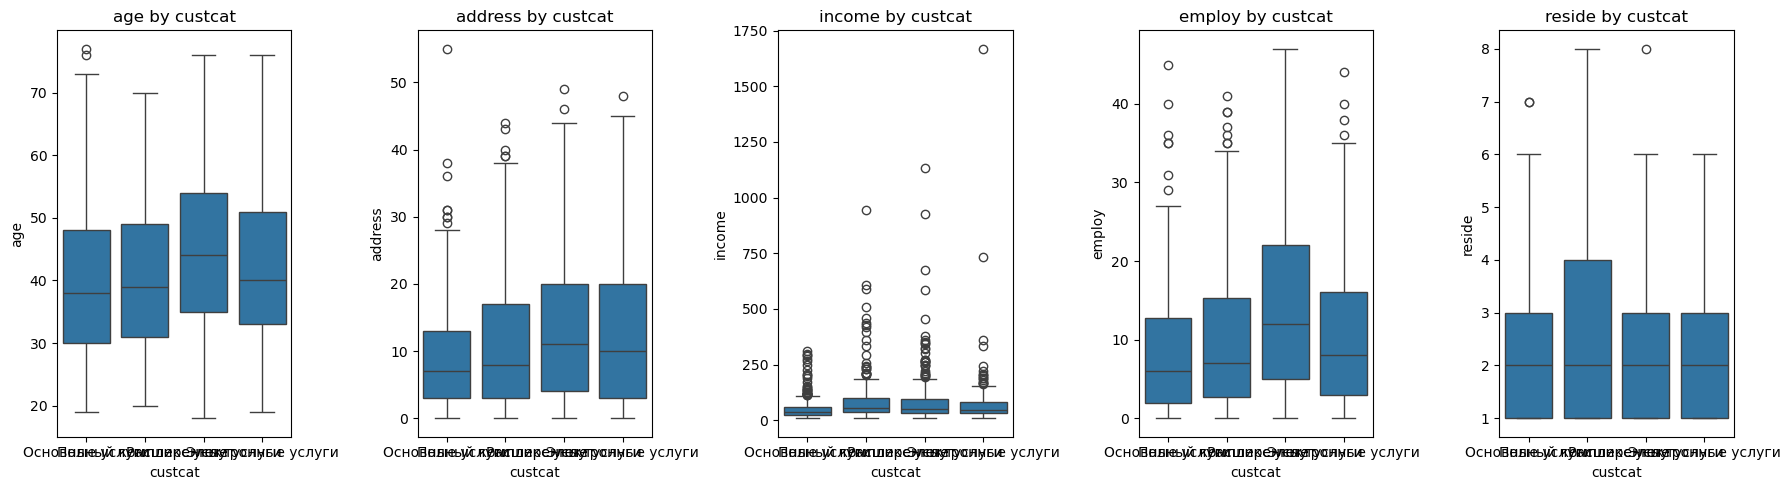

In [7]:
plt.figure(figsize=(18,5))

for i, col in enumerate(numerical_features, 1):
    plt.subplot(1, 5, i)
    sns.boxplot(x='custcat', y=col, data=df)
    plt.title(f'{col} by custcat')

plt.tight_layout()
plt.show()

Практически по всем группам есть отличия.

Рассмотрим корреляцию между признаками.

In [8]:
df[numerical_features].corr(method='spearman')

,age,address,income,employ,reside
age,1.000000,0.636558,0.438600,0.664025,-0.234203
address,0.636558,1.000000,0.299320,0.434598,-0.185508
income,0.438600,0.299320,1.000000,0.637323,-0.089873
employ,0.664025,0.434598,0.637323,1.000000,-0.120918
reside,-0.234203,-0.185508,-0.089873,-0.120918,1.000000


Нет корреляций выше 0.7. Выведем VIFы.

In [9]:
X_vif = df[numerical_features].dropna()

vif = pd.DataFrame()
vif["Признак"] = X_vif.columns

vif["VIF"] = [
    1 / (1 - LinearRegression()
         .fit(X_vif.drop(col, axis=1), X_vif[col])
         .score(X_vif.drop(col, axis=1), X_vif[col]))
    for col in X_vif.columns
]

print(vif.sort_values("VIF", ascending=False))

   Признак       VIF
0      age  2.606236
3   employ  2.221994
1  address  1.780144
2   income  1.366893
4   reside  1.076489


VIFы в пределах нормы.

Проанализируем категориальные признаки.

In [10]:
categorical_features = ['marital', 'ed', 'retire', 'gender']

In [11]:
for col in categorical_features:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False)) 
    print("\n")

--- marital ---
не женат    505
женат       495
Name: marital, dtype: int64


--- ed ---
среднее образование                           287
среднее специальное образование               234
не законченное среднее специальное образов    209
не законченное среднее образование            204
высшее образование                             66
Name: ed, dtype: int64


--- retire ---
нет    953
да      47
Name: retire, dtype: int64


--- gender ---
женский    517
мужской    483
Name: gender, dtype: int64




Все группы достаточно наполнены.

Теперь построим таблицы сопряженности с целевой переменной.

In [12]:
target = "custcat"

for feature in categorical_features:
    print(f"\n --- {feature} --- ")
    
    table = pd.crosstab(df[feature], df[target])
    display(table.style.format("{:.0f}"))


 --- marital --- 


custcat,Основные услуги,Полный комплекс услуг,Расширенные услуги,Электронные услуги
marital,,,,
женат,111,130,139,115
не женат,155,106,142,102



 --- ed --- 


custcat,Основные услуги,Полный комплекс услуг,Расширенные услуги,Электронные услуги
ed,,,,
высшее образование,9,31,4,22
не законченное среднее образование,75,9,91,29
не законченное среднее специальное образов,53,49,54,53
среднее образование,83,52,98,54
среднее специальное образование,46,95,34,59



 --- retire --- 


custcat,Основные услуги,Полный комплекс услуг,Расширенные услуги,Электронные услуги
retire,,,,
да,11,7,22,7
нет,255,229,259,210



 --- gender --- 


custcat,Основные услуги,Полный комплекс услуг,Расширенные услуги,Электронные услуги
gender,,,,
женский,135,121,142,119
мужской,131,115,139,98


Проблемы неполноты информации не наблюдается.

Препроцессинг

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)

Модель

In [14]:
model = LogisticRegression(
    multi_class="multinomial",
    max_iter=1000
)

Пайплайн

In [15]:
pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", model)
])

Определим целевую переменную и признаки.

In [16]:
y = df["custcat"]
X = df[categorical_features + numerical_features]

Разделим на обучающую и тестовую выборки.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

Обучим модель

In [18]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['marital', 'ed', 'retire',
                                                   'gender']),
                                                 ('num', 'passthrough',
                                                  ['age', 'address', 'income',
                                                   'employ', 'reside'])])),
                ('model',
                 LogisticRegression(max_iter=1000, multi_class='multinomial'))])

Метрики на обучающей выборке

Точность: 0.4125 

Матрица ошибок:
[[ 96  40  57  20]
 [ 32  93  36  28]
 [ 70  32 102  21]
 [ 35  53  46  39]]

Расшифровка:
Строки — истинные классы
Столбцы — предсказанные классы

Отчет о классификации:
                        precision    recall  f1-score   support

      Основные услуги       0.41      0.45      0.43       213
Полный комплекс услуг       0.43      0.49      0.46       189
   Расширенные услуги       0.42      0.45      0.44       225
   Электронные услуги       0.36      0.23      0.28       173

             accuracy                           0.41       800
            macro avg       0.41      0.41      0.40       800
         weighted avg       0.41      0.41      0.41       800


ROC-AUC: 0.692


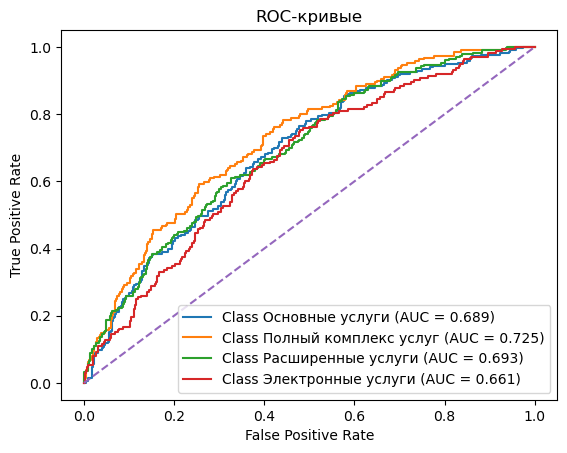

In [19]:
y_train_pred = pipeline.predict(X_train)

print("Метрики на обучающей выборке\n")

print("Точность:", accuracy_score(y_train, y_train_pred), '\n')

cm = confusion_matrix(y_train, y_train_pred)
print("Матрица ошибок:")
print(cm)

print("\nРасшифровка:")
print("Строки — истинные классы")
print("Столбцы — предсказанные классы")

print("\nОтчет о классификации:\n", classification_report(y_train, y_train_pred))


y_train_proba = pipeline.predict_proba(X_train)

classes = np.unique(y_train)
y_train_bin = label_binarize(y_train, classes=classes)

roc_auc = roc_auc_score(y_train_bin, y_train_proba, multi_class="ovr")
print(f"\nROC-AUC: {roc_auc:.3f}")

plt.figure()

for i, class_label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_train_bin[:, i], y_train_proba[:, i])
    auc_score = roc_auc_score(y_train_bin[:, i], y_train_proba[:, i])
    plt.plot(fpr, tpr, label=f"Class {class_label} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривые")
plt.legend()
plt.show()

Метрики на тестовой выборке

Точность: 0.385 

Матрица ошибок:
[[20 12 13  8]
 [ 5 24  7 11]
 [15  7 28  6]
 [12 12 15  5]]

Расшифровка:
Строки — истинные классы
Столбцы — предсказанные классы

Отчет о классификации:
                        precision    recall  f1-score   support

      Основные услуги       0.38      0.38      0.38        53
Полный комплекс услуг       0.44      0.51      0.47        47
   Расширенные услуги       0.44      0.50      0.47        56
   Электронные услуги       0.17      0.11      0.14        44

             accuracy                           0.38       200
            macro avg       0.36      0.38      0.36       200
         weighted avg       0.37      0.39      0.37       200


ROC-AUC: 0.651


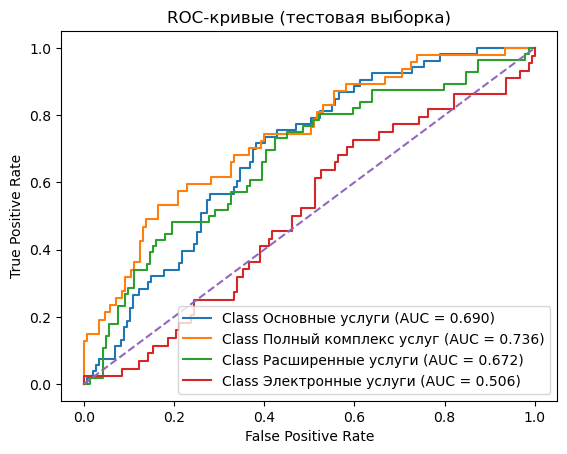

In [20]:
y_test_pred = pipeline.predict(X_test)

print("Метрики на тестовой выборке\n")

print("Точность:", accuracy_score(y_test, y_test_pred), '\n')

cm = confusion_matrix(y_test, y_test_pred)
print("Матрица ошибок:")
print(cm)

print("\nРасшифровка:")
print("Строки — истинные классы")
print("Столбцы — предсказанные классы")

print("\nОтчет о классификации:\n", classification_report(y_test, y_test_pred))

y_test_proba = pipeline.predict_proba(X_test)

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

roc_auc = roc_auc_score(y_test_bin, y_test_proba, multi_class="ovr")
print(f"\nROC-AUC: {roc_auc:.3f}")

plt.figure()

for i, class_label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_proba[:, i])
    auc_score = roc_auc_score(y_test_bin[:, i], y_test_proba[:, i])
    plt.plot(fpr, tpr, label=f"Class {class_label} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривые (тестовая выборка)")
plt.legend()
plt.show()

Класс "Электронные услуги" плохо предсказан.

Теперь выведем отношения шансов.

In [21]:
model = next(s for s in pipeline.named_steps.values() if hasattr(s, "coef_"))
classes = model.classes_

features = next((s.get_feature_names_out() for s in pipeline.named_steps.values() if hasattr(s, "get_feature_names_out")),
                [f"f{i}" for i in range(model.coef_.shape[1])])

df_or = pd.DataFrame({
    f"{classes[i]} vs {classes[j]}": np.exp(model.coef_[i] - model.coef_[j])
    for i, j in combinations(range(len(classes)), 2)
}, index=features)

df_or

,Основные услуги vs Полный комплекс услуг,Основные услуги vs Расширенные услуги,Основные услуги vs Электронные услуги,Полный комплекс услуг vs Расширенные услуги,Полный комплекс услуг vs Электронные услуги,Расширенные услуги vs Электронные услуги
cat__marital_не женат,1.162278,1.237820,1.508961,1.064995,1.298279,1.219047
cat__ed_не законченное среднее образование,19.639507,0.733684,9.172999,0.037358,0.467069,12.502658
cat__ed_не законченное среднее специальное образов,2.854752,0.685766,2.029778,0.240219,0.711017,2.959869
cat__ed_среднее образование,4.136852,0.694724,3.542988,0.167935,0.856445,5.099848
cat__ed_среднее специальное образование,1.335811,0.967283,1.675150,0.724117,1.254032,1.731809
cat__retire_нет,0.695673,1.468935,0.378131,2.111532,0.543547,0.257418
cat__gender_мужской,0.995868,0.938003,1.354271,0.941894,1.359889,1.443781
num__age,1.009563,1.018285,1.010945,1.008640,1.001369,0.992792
num__address,0.975890,0.973565,0.953607,0.997617,0.977167,0.979500
num__income,0.997405,0.996856,1.002941,0.999449,1.005551,1.006105


Интерпретация:

- Шансы неженатых выбрать основные услуги (по сравнению с полным комплексом) на 16% выше, чем у женатых.
- Шансы людей с незаконченным средним образованием выбрать основные услуги (по сравнению с полным комплексом) в 19,6 раза выше, чем у людей с высшим образованием.
- Увеличение возраста на год повышает шансы выбрать основные услуги (по сравнению с полным комплексом) на 0,9%.

Выведем предельные эффекты.

In [22]:
m = next(s for s in pipeline.named_steps.values() if hasattr(s,"coef_"))
f = next((s.get_feature_names_out() for s in pipeline.named_steps.values() if hasattr(s,"get_feature_names_out")),
         [f"f{i}" for i in range(m.coef_.shape[1])])

x = pipeline[:-1].transform(X_test).mean(axis=0).ravel()
W = m.coef_

p = np.exp((x @ W.T) - np.max(x @ W.T))
p /= p.sum()

df_mfx = pd.DataFrame((p[:,None] * (W - (p @ W)[None,:])).T, index=f, columns=m.classes_)

df_mfx

,Основные услуги,Полный комплекс услуг,Расширенные услуги,Электронные услуги
cat__marital_не женат,0.044807,0.011178,-0.004421,-0.051564
cat__ed_не законченное среднее образование,0.255746,-0.427114,0.433684,-0.262316
cat__ed_не законченное среднее специальное образов,0.067945,-0.173223,0.203835,-0.098557
cat__ed_среднее образование,0.118658,-0.207075,0.267482,-0.179065
cat__ed_среднее специальное образование,0.041075,-0.024890,0.064705,-0.080890
cat__retire_нет,-0.046060,0.036759,-0.176884,0.186185
cat__gender_мужской,0.012023,0.013306,0.035244,-0.060573
num__age,0.002320,0.000178,-0.002353,-0.000145
num__address,-0.005688,-0.000187,0.000474,0.005401
num__income,-0.000189,0.000408,0.000695,-0.000914


Интерпретация:

- У неженатых вероятность выбрать основные услуги (по сравнению с полным комплексом) на 4.5 процентных пункта выше, чем у женатых.
- У людей с незаконченным средним образованием вероятность выбрать основные услуги (по сравнению с полным комплексом) на 26 процентных пунктов выше, чем у людей с высшим образованием.
- Увеличение возраста на год повышает вероятность выбрать основные услуги (по сравнению с полным комплексом) на 0,2 процентных пункта.

### Часть 2. kNN

In [23]:
knn = KNeighborsClassifier(
    n_neighbors=5,       # 5 соседей
    metric="minkowski", 
    p=2  # евклидово расстояние
)

pipeline_knn = Pipeline([
    ("preprocess", preprocessor),
    ("knn", knn)
])

pipeline_knn.fit(X_train, y_train)

y_pred = pipeline_knn.predict(X_test)
y_proba = pipeline_knn.predict_proba(X_test)

print("Точность на тестовой выборке:", accuracy_score(y_test, y_pred))

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

roc_auc = roc_auc_score(y_test_bin, y_proba, multi_class="ovr")
print("ROC-AUC:", round(roc_auc, 4))

print("\nМатрица ошибок:\n", confusion_matrix(y_test, y_pred))

print("\nОтчет о классификации:\n", classification_report(y_test, y_pred))

Точность на тестовой выборке: 0.33
ROC-AUC: 0.5296

Матрица ошибок:
 [[28 10 11  4]
 [17 14 11  5]
 [24  7 21  4]
 [17  5 19  3]]

Отчет о классификации:
                        precision    recall  f1-score   support

      Основные услуги       0.33      0.53      0.40        53
Полный комплекс услуг       0.39      0.30      0.34        47
   Расширенные услуги       0.34      0.38      0.36        56
   Электронные услуги       0.19      0.07      0.10        44

             accuracy                           0.33       200
            macro avg       0.31      0.32      0.30       200
         weighted avg       0.31      0.33      0.31       200



Попробуем подобрать оптимальное значение k. Для этого применим GridSearchCV.

In [24]:
param_grid = {
    "knn__n_neighbors": list(range(1, 31, 1))  # 1, 2, 3, ... 29
}

grid = GridSearchCV(
    pipeline_knn,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Лучшее значение k:", grid.best_params_)
print("Точность на кросс-валидации:", grid.best_score_)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("\nТочность на тестовой выборке:", accuracy_score(y_test, y_pred))
print("\nМатрица ошибок:\n", confusion_matrix(y_test, y_pred))
print("\nОтчет о классификации:\n", classification_report(y_test, y_pred))

Лучшее значение k: {'knn__n_neighbors': 24}
Точность на кросс-валидации: 0.32625

Точность на тестовой выборке: 0.28

Матрица ошибок:
 [[23  8 15  7]
 [17  7 18  5]
 [21  8 24  3]
 [19  7 16  2]]

Отчет о классификации:
                        precision    recall  f1-score   support

      Основные услуги       0.29      0.43      0.35        53
Полный комплекс услуг       0.23      0.15      0.18        47
   Расширенные услуги       0.33      0.43      0.37        56
   Электронные услуги       0.12      0.05      0.07        44

             accuracy                           0.28       200
            macro avg       0.24      0.26      0.24       200
         weighted avg       0.25      0.28      0.25       200



Визуализируем

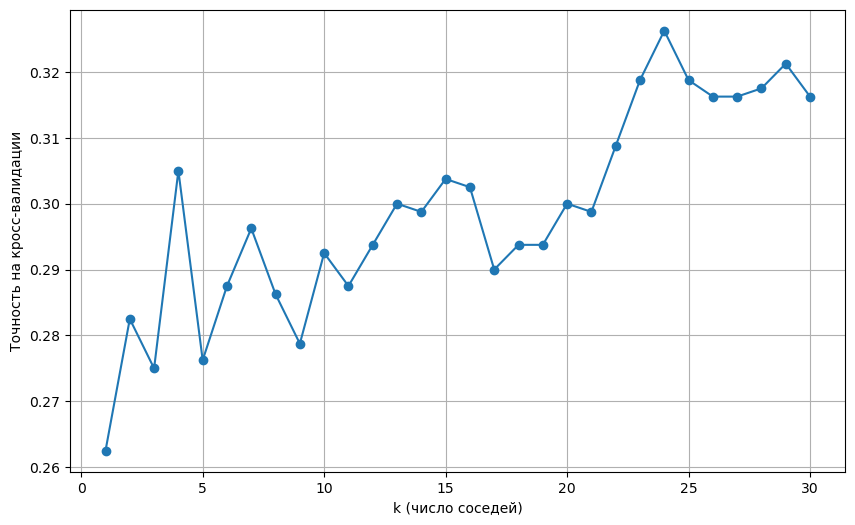


---Лучшие параметры---
Лучшее значение k: 24
Лучшая точность на кросс-валидации: 0.32625


In [25]:
k_values = list(range(1, 31))

cv_scores = []

for k in k_values:
    
    model = Pipeline([
        ("preprocess", best_model.named_steps["preprocess"]),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )
    
    cv_scores.append(scores.mean())

plt.figure(figsize=(10,6))
plt.plot(k_values, cv_scores, marker="o")

plt.xlabel("k (число соседей)")
plt.ylabel("Точность на кросс-валидации")
plt.grid(True)
plt.show()

best_k = k_values[np.argmax(cv_scores)]

print("\n---Лучшие параметры---")
print("Лучшее значение k:", best_k)
print("Лучшая точность на кросс-валидации:", max(cv_scores))

Посмотрим как меняется точность на обучающей и тестовой выборках при разных k.

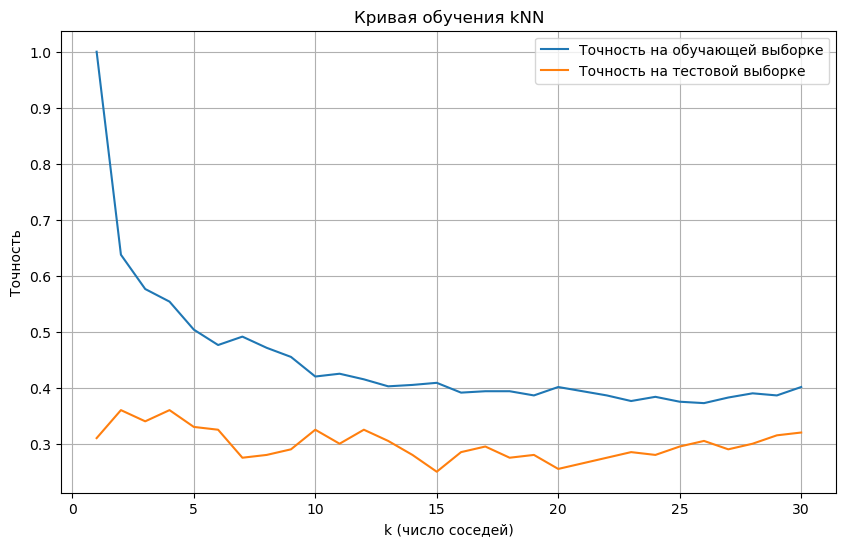


---Лучшие параметры___
Лучшее значение k: 2
Лучшая точность на кросс-валидации: 0.36


In [26]:
k_values = list(range(1, 31))

train_scores = []
test_scores = []

for k in k_values:
    
    model = Pipeline([
        ("preprocess", best_model.named_steps["preprocess"]),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_scores.append(accuracy_score(y_train, y_train_pred))
    test_scores.append(accuracy_score(y_test, y_test_pred))

plt.figure(figsize=(10,6))

plt.plot(k_values, train_scores, label="Точность на обучающей выборке")
plt.plot(k_values, test_scores, label="Точность на тестовой выборке")

plt.xlabel("k (число соседей)")
plt.ylabel("Точность")
plt.title("Кривая обучения kNN")
plt.legend()
plt.grid(True)

plt.show()

best_k = k_values[np.argmax(test_scores)]

print("\n---Лучшие параметры___")
print("Лучшее значение k:", best_k)
print("Лучшая точность на кросс-валидации:", max(test_scores))

Оценим важность признаков.

In [27]:
result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

import pandas as pd

imp = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result.importances_mean
}).sort_values("importance", ascending=False)

imp

,feature,importance
8,reside,0.0055
3,gender,0.0020
6,income,0.0015
7,employ,0.0005
0,marital,0.0000
2,retire,0.0000
1,ed,-0.0010
5,address,-0.0190
4,age,-0.0300


Permutation importance в scikit-learn оценивает важность признаков, измеряя, насколько ухудшается качество модели при случайном перемешивании значений каждого признака. Сначала считается базовое значение метрики на тестовых данных, затем для каждого признака его значения перемешиваются, что разрушает связь с целевой переменной, и модель снова оценивается. Разница между исходным и новым качеством усредняется по нескольким повторениям (`n_repeats`) и принимается за важность: чем сильнее падает метрика, тем важнее признак для модели.

Чем больше значение, тем важнее признак. Если отрицательное, то признак ухудшает модель. В нашей модели самый важный признак - получение пенсии (reside), потому что его перемешивание сильнее всего ухудшает качество модели

Но в целом все значения очень маленькие, это сигнализирует о том, что модель почти не опирается на отдельные признаки.

# Задание для работы на семинаре

### Данные о сотрудниках

[Информация о данных](https://www.kaggle.com/datasets/rhuebner/human-resources-data-set/data)

| Признак | Описание |
|------|----------|
| Employee Name | Полное имя сотрудника |
| EmpID | Уникальный идентификатор сотрудника |
| MarriedID | Состоит ли сотрудник в браке (1 — да, 0 — нет) |
| MaritalStatusID | Код семейного положения, соответствующий полю MaritalDesc |
| EmpStatusID | Код статуса занятости, соответствующий полю EmploymentStatus |
| DeptID | Код отдела, в котором работает сотрудник |
| PerfScoreID | Код оценки эффективности сотрудника |
| FromDiversityJobFairID | Был ли сотрудник нанят через ярмарку вакансий (1 — да, 0 — нет) |
| Salary | Годовая зарплата сотрудника (в долларах США) |
| Termd | Был ли сотрудник уволен (1 — да, 0 — нет) |
| PositionID | Идентификатор должности сотрудника |
| Position | Название должности |
| State | Штат проживания сотрудника |
| Zip | Почтовый индекс сотрудника |
| DOB | Дата рождения сотрудника |
| Sex | Пол сотрудника (M или F) |
| MaritalDesc | Cемейное положение |
| CitizenDesc | Статус гражданства |
| HispanicLatino | Относит ли себя сотрудник к латиноамериканскому происхождению (да/нет) |
| RaceDesc | Расовая принадлежность сотрудника |
| DateofHire | Дата приема на работу |
| DateofTermination | Дата увольнения (заполнено только если Termd = 1) |
| TermReason | Причина увольнения |
| EmploymentStatus | Статус занятости (например, Active — работает полный день) |
| Department | Название отдела |
| ManagerName | Имя непосредственного руководителя |
| ManagerID | Уникальный идентификатор руководителя |
| RecruitmentSource | Источник найма сотрудника |
| PerformanceScore | Оценка эффективности |
| EngagementSurvey | Результат последнего опроса вовлеченности |
| EmpSatisfaction | Уровень удовлетворенности сотрудника |
| SpecialProjectsCount | Количество специальных проектов за последние 6 месяцев |
| LastPerformanceReviewDate | Дата последней оценки эффективности |
| DaysLateLast30 | Количество опозданий за последние 30 дней |
| Absences | Количество пропусков работы |

In [28]:
df = pd.read_csv("HRDataset.csv")

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee_Name               311 non-null    object 
 1   EmpID                       311 non-null    int64  
 2   MarriedID                   311 non-null    int64  
 3   MaritalStatusID             311 non-null    int64  
 4   GenderID                    311 non-null    int64  
 5   EmpStatusID                 311 non-null    int64  
 6   DeptID                      311 non-null    int64  
 7   PerfScoreID                 311 non-null    int64  
 8   FromDiversityJobFairID      311 non-null    int64  
 9   Salary                      311 non-null    int64  
 10  Termd                       311 non-null    int64  
 11  PositionID                  311 non-null    int64  
 12  Position                    311 non-null    object 
 13  State                       311 non

**Задание: На основе алгоритма kNN постройте модель для предсказания зарплаты. Оцените параметры модели.**

In [ ]:
# здесь написать решение